In [1]:
import pandas as pd
import glob
from tqdm import tqdm

raw_baseline_data = []
raw_learned_data = []
raw_learned_no_perturb_data = []

for file in tqdm(sorted(glob.glob("./data/lifting_trials_baseline_lhs_1000_hugger/trials/*.json"))):
    raw_baseline_data.append(pd.read_json(file))


for file in tqdm(sorted(glob.glob("./data/lifting_trials_k1b5sgl8_lhs_1000_rl_model_38997816_steps/trials/*.json"))):
    raw_learned_data.append(pd.read_json(file))
    

for file in tqdm(sorted(glob.glob("./data/lifting_trials_k1b5sgl8_lhs_1000_rl_model_38997816_steps_no_perturb/*.json"))):
    raw_learned_no_perturb_data.append(pd.read_json(file))

100%|██████████| 1000/1000 [00:18<00:00, 54.91it/s]


In [2]:
raw_baseline_data[0]

,xsize,ysize,zsize,mass,xpos,rotation,success,tip_rate,slip_rate,avg_episode_length,action_hist,observation_hist,info_hist,video
0,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[-1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.998709142208099, -0.063852086663246, -0.063...","{'reward_terms': {'dont_drop': 0.0}, 'is_succe...",trial_0.mp4
1,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[-1.0, 0.01156462585034, 0.0, 0.00612244897959...","[0.99868106842041, -0.065609604120254, -0.0649...","{'reward_terms': {'dont_drop': 0.0}, 'is_succe...",trial_0.mp4
2,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[-1.0, 0.02312925170068, 0.0, 0.01224489795918...","[0.9985182285308831, -0.068393617868423, -0.06...","{'reward_terms': {'dont_drop': 0.0}, 'is_succe...",trial_0.mp4
3,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[-1.0, 0.034693877551020005, 0.0, 0.0183673469...","[0.9982669353485101, -0.071866132318973, -0.07...","{'reward_terms': {'dont_drop': 0.0}, 'is_succe...",trial_0.mp4
4,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[-1.0, 0.04625850340136, 0.0, 0.02448979591836...","[0.997926890850067, -0.075619645416736, -0.075...","{'reward_terms': {'dont_drop': 0.0}, 'is_succe...",trial_0.mp4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[1.0, 0.0, 1.0, -0.6666666666666661, 1.0, 0.0,...","[0.6529574394226071, 0.10754293948411901, 0.14...","{'reward_terms': {'dont_drop': 3.99}, 'is_succ...",trial_0.mp4
1140,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[1.0, 0.0, 1.0, -0.6666666666666661, 1.0, 0.0,...","[0.654936432838439, 0.10694897174835201, 0.140...","{'reward_terms': {'dont_drop': 4.0}, 'is_succe...",trial_0.mp4
1141,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[1.0, 0.0, 1.0, -0.6666666666666661, 1.0, 0.0,...","[0.656959652900695, 0.10640800744295101, 0.139...","{'reward_terms': {'dont_drop': 4.01}, 'is_succ...",trial_0.mp4
1142,0.242245,0.234312,0.422928,1.072875,0.051219,0.83362,True,False,False,1144,"[1.0, 0.0, 1.0, -0.6666666666666661, 1.0, 0.0,...","[0.6589750647544861, 0.10588463395833901, 0.13...","{'reward_terms': {'dont_drop': 4.02}, 'is_succ...",trial_0.mp4


In [3]:
#loop through all 1000 dataframes and extract inputs size, xpos, rotation, and outcome. Put into new dataframe
def extract_episode_metadata(raw_data):
    trials_summary = []
    for trial_df in raw_data:
        first_row = trial_df.iloc[0]
        trials_summary.append({
            "xsize": first_row['xsize'],
            "ysize": first_row["ysize"],
            "zsize": first_row["zsize"],
            "mass": first_row["mass"],
            "xpos": first_row["xpos"],
            "rotation": first_row["rotation"],
            "success": first_row["success"],
            "tip": first_row["tip_rate"],
            "slip": first_row["slip_rate"],
        })

    trials_summary_df = pd.DataFrame(trials_summary)
    return trials_summary_df


learned_summary = extract_episode_metadata(raw_learned_data)
baseline_summary = extract_episode_metadata(raw_baseline_data)
learned_no_perturb_summary = extract_episode_metadata(raw_learned_no_perturb_data)

In [4]:
# Define the key columns for merging
key_cols = ['xsize', 'ysize', 'zsize', 'mass', 'xpos', 'rotation']

# Merge on those columns with suffixes to distinguish the two datasets
merged_df = pd.merge(baseline_summary,
                     learned_summary,
                     on=key_cols,
                     suffixes=('_baseline', '_learned'))

full_df = pd.merge(merged_df, learned_no_perturb_summary, on=key_cols)

full_df.rename(columns={
    'slip': 'slip_learned_no_perturb',
    'success': 'success_learned_no_perturb',
    'tip': 'tip_learned_no_peturb'
},
               inplace=True)

full_df

,xsize,ysize,zsize,mass,xpos,rotation,success_baseline,tip_baseline,slip_baseline,success_learned,tip_learned,slip_learned,success_learned_no_perturb,tip_learned_no_peturb,slip_learned_no_perturb
0,0.242245,0.234312,0.422928,1.072875,0.051219,0.833620,True,False,False,True,False,False,True,False,False
1,0.120048,0.272243,0.451702,5.027221,0.013726,0.881587,True,False,False,True,False,False,True,False,False
2,0.165666,0.206906,0.587663,9.356233,0.040727,0.074239,True,False,False,True,False,False,True,False,False
3,0.272104,0.122048,0.614161,3.561653,0.010007,0.232021,True,False,False,True,False,False,True,False,False
4,0.278227,0.274777,0.599600,9.986319,0.094911,0.064202,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.260523,0.205391,0.391549,2.457044,0.036994,0.454947,True,False,False,True,False,False,True,False,False
996,0.210849,0.285531,0.536815,4.540674,0.021900,0.287897,True,False,False,True,False,False,True,False,False
997,0.100235,0.183333,0.270000,5.997021,0.088591,0.849533,False,False,True,False,False,True,True,False,False
998,0.181010,0.225303,0.572459,3.058466,0.015007,0.427064,True,False,False,True,False,False,True,False,False


In [5]:
condition = ((merged_df['slip_baseline'] > 0)
             & (merged_df['tip_learned'] == True))
switched_outcomes = merged_df[condition]
switched_outcomes

,xsize,ysize,zsize,mass,xpos,rotation,success_baseline,tip_baseline,slip_baseline,success_learned,tip_learned,slip_learned
6,0.103775,0.279992,0.254583,1.331348,0.085597,0.639911,False,False,True,False,True,False
26,0.285351,0.167587,0.268204,8.541597,0.054537,0.439716,False,False,True,False,True,False
36,0.171149,0.234616,0.273080,6.897267,0.004797,0.943235,False,False,True,False,True,False
93,0.183542,0.208148,0.260280,8.523605,0.027244,0.697048,False,False,True,False,True,False
163,0.196413,0.194562,0.253710,5.359272,0.013896,0.294280,False,False,True,False,True,False
189,0.102033,0.133157,0.410123,2.052574,0.087799,0.649182,False,False,True,False,True,False
199,0.136390,0.115627,0.429135,5.833120,0.011248,0.799790,False,False,True,False,True,False
203,0.233099,0.172099,0.265532,8.115247,0.034557,0.703535,False,False,True,False,True,False
240,0.259933,0.276334,0.252202,6.340707,0.035830,0.514287,False,False,True,False,True,False
241,0.159154,0.242248,0.258792,6.541799,0.001737,0.593085,False,False,True,False,True,False


In [6]:
def label_outcome(row, prefix):
    if row[f'tip_{prefix}']:
        return 'tip'
    elif row[f'slip_{prefix}'] > 0:
        return 'slip'
    elif row[f'success_{prefix}']:
        return 'success'


merged_df['baseline_outcome'] = merged_df.apply(lambda row: label_outcome(row, 'baseline'), axis=1)
merged_df['learned_outcome'] = merged_df.apply(lambda row: label_outcome(row, 'learned'), axis=1)
merged_df

,xsize,ysize,zsize,mass,xpos,rotation,success_baseline,tip_baseline,slip_baseline,success_learned,tip_learned,slip_learned,baseline_outcome,learned_outcome
0,0.242245,0.234312,0.422928,1.072875,0.051219,0.833620,True,False,False,True,False,False,success,success
1,0.120048,0.272243,0.451702,5.027221,0.013726,0.881587,True,False,False,True,False,False,success,success
2,0.165666,0.206906,0.587663,9.356233,0.040727,0.074239,True,False,False,True,False,False,success,success
3,0.272104,0.122048,0.614161,3.561653,0.010007,0.232021,True,False,False,True,False,False,success,success
4,0.278227,0.274777,0.599600,9.986319,0.094911,0.064202,True,False,False,True,False,False,success,success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.260523,0.205391,0.391549,2.457044,0.036994,0.454947,True,False,False,True,False,False,success,success
996,0.210849,0.285531,0.536815,4.540674,0.021900,0.287897,True,False,False,True,False,False,success,success
997,0.100235,0.183333,0.270000,5.997021,0.088591,0.849533,False,False,True,False,False,True,slip,slip
998,0.181010,0.225303,0.572459,3.058466,0.015007,0.427064,True,False,False,True,False,False,success,success


In [7]:
transition_counts = merged_df.groupby(['baseline_outcome', 'learned_outcome'
                                       ]).size().reset_index(name='count')
transition_counts

,baseline_outcome,learned_outcome,count
0,slip,slip,44
1,slip,success,20
2,slip,tip,48
3,success,slip,2
4,success,success,815
5,success,tip,5
6,tip,slip,4
7,tip,success,15
8,tip,tip,47


In [8]:
#print out the data of the cases that initially succeeded, but failed after learning
success_then_tip_cases = merged_df[(merged_df['baseline_outcome'] == 'success')
                                   & (merged_df['learned_outcome'] == 'tip')]
success_then_tip_cases

,xsize,ysize,zsize,mass,xpos,rotation,success_baseline,tip_baseline,slip_baseline,success_learned,tip_learned,slip_learned,baseline_outcome,learned_outcome
9,0.267065,0.211657,0.293585,7.360278,0.035452,0.155402,True,False,False,False,True,False,success,tip
113,0.298083,0.143470,0.324968,0.961550,0.045192,0.396900,True,False,False,False,True,False,success,tip
322,0.242714,0.293062,0.295049,0.790989,0.085686,0.330770,True,False,False,False,True,False,success,tip
651,0.289536,0.141434,0.370836,7.069247,0.001754,0.101092,True,False,False,False,True,False,success,tip
864,0.251369,0.166423,0.281362,4.470527,0.041266,0.084048,True,False,False,False,True,False,success,tip


In [9]:
import plotly.graph_objects as go

def create_sankey_diagram(transition_counts, outcome_labels, title="Baseline → Learned Outcome Transitions"):
    """
    Creates a Sankey diagram showing transitions from baseline outcomes to learned outcomes.

    Parameters:
    - transition_counts: DataFrame with columns ['baseline_outcome', 'learned_outcome', 'count']
    - outcome_labels: list of unique outcome labels (e.g. ['success', 'slipped', 'tipped'])
    - title: figure title string
    """

    # Map outcome labels to node indices
    label_to_index = {label: idx for idx, label in enumerate(outcome_labels)}
    
    # Sources (baseline nodes)
    source_indices = transition_counts['baseline_outcome'].map(label_to_index).tolist()
    # Targets (learned nodes), offset by number of baseline nodes to place on right
    target_indices = transition_counts['learned_outcome'].map(lambda x: label_to_index[x] + len(outcome_labels)).tolist()
    
    # Flow values (number of trials)
    values = transition_counts['count'].tolist()
    
    # All node labels: baseline + learned (duplicated for left and right columns)
    node_labels = outcome_labels + outcome_labels

    # Optional: define consistent colors for nodes
    node_colors = ['#4C78A8', '#F58518', '#E45756'] * 2  # repeat for baseline and learned
    
    # Build Sankey diagram
    sankey_fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=node_labels,
            color=node_colors,
            hovertemplate='%{label}<extra></extra>'
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=values,
            color='rgba(150, 150, 150, 0.4)',  # semi-transparent grey links
            hovertemplate='Count: %{value}<extra></extra>'
        )
    )])

    # Update layout with professional formatting
    sankey_fig.update_layout(
        title_text=None,
        font=dict(size=24, family='Times New Roman, Times, serif'),
        height=400,
        margin=dict(l=30, r=30, t=50, b=20),  # add bottom margin for labels
        annotations=[
            dict(
                x=0.02,  # left group
                y=1.15,  # slightly below the plot (negative to go below axis)
                text="Baseline",
                showarrow=False,
                font=dict(size=24, family='Times New Roman, Times, serif'),
                xanchor='center',
                yanchor='top'  # align text above this y-position
            ),
            dict(
                x=0.98,  # right group
                y=1.15,
                text="Learned",
                showarrow=False,
                font=dict(size=24, family='Times New Roman, Times, serif'),
                xanchor='center',
                yanchor='top'
            )
        ]
    )

    return sankey_fig

# Usage example:
fig = create_sankey_diagram(transition_counts, ['success', 'slip', 'tip'])
fig.show()


In [10]:
# Create pivot table (transition matrix)
transition_matrix = transition_counts.pivot(
    index='baseline_outcome',
    columns='learned_outcome',
    values='count'
).fillna(0).astype(int)

print(transition_matrix)


learned_outcome   slip  success  tip
baseline_outcome                    
slip                44       20   48
success              2      815    5
tip                  4       15   47


## Did learning statistically affect outcomes?

using stuart-maxwell test b/c my data is technically paired (since each box was used for a baseline run and a learned run. If they were independent chi square would be the test with the contingency table. )

In [11]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(transition_matrix)

print(f"Chi-squared: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected counts:")

print(expected)


Chi-squared: 850.2462272234707
p-value: 1.002103826731177e-182
Degrees of freedom: 4
Expected counts:
[[  5.6  95.2  11.2]
 [ 41.1 698.7  82.2]
 [  3.3  56.1   6.6]]


since this data was on paired data, but the same objects were not necessarily perturbed in the same way, the stuart-maxwell test isn't exactly right. The above chi squared also isn't exactly right. But they both have miniscule p-values, so I think its safe to say that learning did something under perturbation too. 

In [12]:
import numpy as np
from statsmodels.stats.contingency_tables import SquareTable

table = SquareTable(transition_matrix)

results = table.homogeneity(method="stuart_maxwell")
print(f"chi2 stat:{results.statistic}, pvalue:{results.pvalue}, dof:{results.df}")

chi2 stat:54.52743902439025, pvalue:1.443845043525016e-12, dof:2


# What did actions do in response to perturbations?

In [13]:
#find me the index of a case which was a slip, but turned into a fail?
slip_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'slip')
    & (merged_df['learned_outcome'] == 'success')]
slip_then_success_cases

,xsize,ysize,zsize,mass,xpos,rotation,success_baseline,tip_baseline,slip_baseline,success_learned,tip_learned,slip_learned,baseline_outcome,learned_outcome
92,0.121847,0.121047,0.622945,9.017164,0.026448,0.891468,False,False,True,True,False,False,slip,success
165,0.105081,0.158754,0.583511,3.197517,0.051004,0.899608,False,False,True,True,False,False,slip,success
216,0.118019,0.183416,0.334250,9.333393,0.069442,0.202968,False,False,True,True,False,False,slip,success
269,0.184543,0.250242,0.292888,1.545673,0.008996,0.839764,False,False,True,True,False,False,slip,success
281,0.177657,0.265601,0.276122,9.190953,0.016304,0.266966,False,False,True,True,False,False,slip,success
413,0.134742,0.226664,0.286355,4.756419,0.029604,0.851872,False,False,True,True,False,False,slip,success
431,0.167768,0.165665,0.281103,4.009397,0.001937,0.809668,False,False,True,True,False,False,slip,success
440,0.263906,0.235270,0.267952,8.224159,0.044701,0.965138,False,False,True,True,False,False,slip,success
455,0.170016,0.154350,0.288668,8.403073,0.086470,0.337652,False,False,True,True,False,False,slip,success
497,0.199103,0.223093,0.265254,6.864000,0.054333,0.969775,False,False,True,True,False,False,slip,success


## Slip -> Success

In [14]:
#plot data over time, and highlight in red then the perturbations are active for one trial
single_trial_df = raw_learned_data[440]
baseline_trial_df = raw_baseline_data[440]

1120 2400


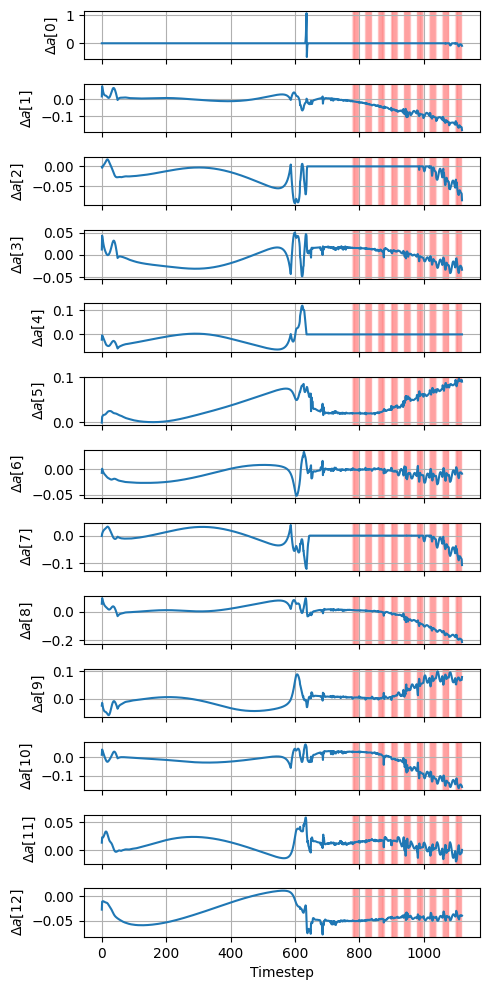

In [15]:
import matplotlib.pyplot as plt


def plot_trial_actions_against_baseline(trial_df,
                                        baseline_df,
                                        save_filename=None):

    actions_over_time = np.stack(trial_df["action_hist"])
    baseline_actions_over_time = np.stack(baseline_df["action_hist"])
    print(len(actions_over_time), len(baseline_actions_over_time))

    perturb_flags = trial_df['info_hist'].apply(
        lambda d: d['perturbation_enabled']).values

    fig, axes = plt.subplots(13, 1, figsize=(5, 10), sharex=True)

    smallest_length = min(len(actions_over_time[:, 0]),
                          len(baseline_actions_over_time[:, 0]))

    for i in range(13):
        ax = axes[i]
        ax.set_ylabel(f"$\Delta a[{i}]$")
        ax.plot(actions_over_time[:smallest_length, i] -
                baseline_actions_over_time[:smallest_length, i])

        # ax.plot(baseline_actions_over_time[:smallest_length,i])
        # ax.set_ylim(-1.1, 1.1)  # adjust based on action range
        ax.grid()
        # Shade red where perturbation is enabled
        for t in range(len(perturb_flags[:smallest_length])):
            if perturb_flags[t]:
                ax.axvspan(t - 0., t + 0., color='red', alpha=0.1)

    axes[-1].set_xlabel('Timestep')
    plt.tight_layout()

    if save_filename is not None:
        plt.savefig(save_filename+".png", dpi=300, bbox_inches='tight', format='png')
    plt.show()

plot_trial_actions_against_baseline(single_trial_df, baseline_trial_df)

### Success -> Success
baseline to perturbed

1075 1144


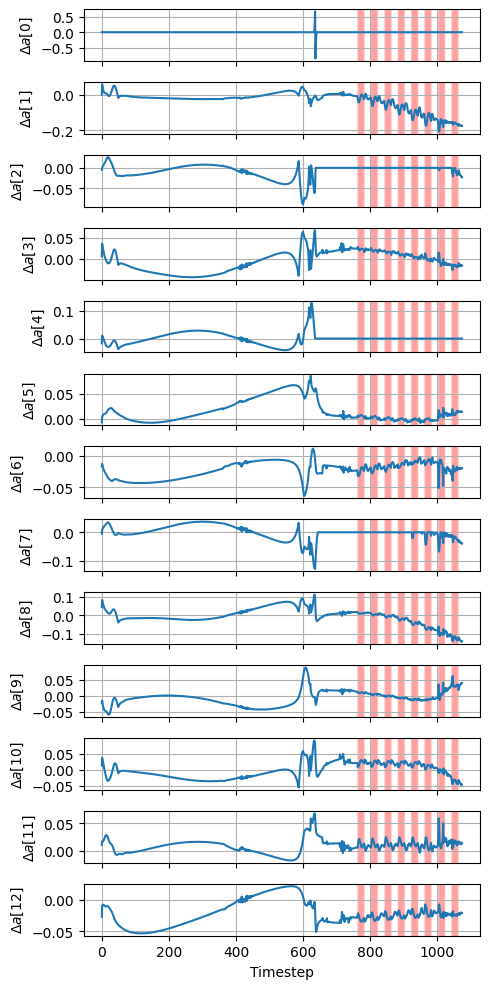

In [16]:
single_trial_df = raw_learned_data[0]
baseline_trial_df = raw_baseline_data[0]

plot_trial_actions_against_baseline(single_trial_df, baseline_trial_df)

So it varies from the baseline somewhat substantially still. But this is the wrong comparison to be making. I should be seeing what actions are chosen by the policy when NOT being perturbed. This will help normalize out the actions differing from the baseline in the first place. If they aren't different at all, then it appears the actions chosen by the policy during approach account for most of the improvements.

There do appear to be differences in the values of the above two plots. 

#### No perturb -> perturb

1120 1082


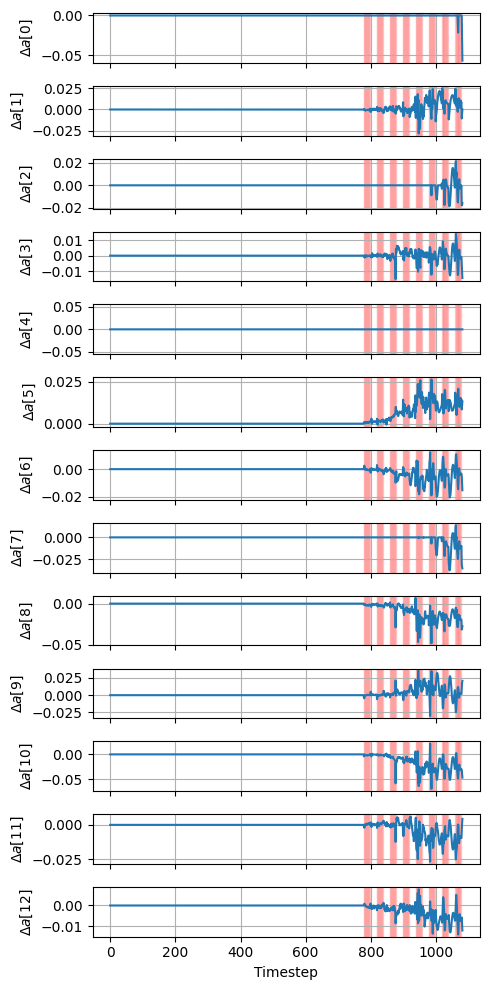

In [17]:
single_trial_df = raw_learned_data[440]
single_trial_df_no_perturb = raw_learned_no_perturb_data[440]

plot_trial_actions_against_baseline(single_trial_df, single_trial_df_no_perturb, "slip_to_success_coorective_action_vector")

So there are differences in response to perturbations. Great. Is there any way to tell if the policy WOULD HAVE failed if those differences hadn't happened? Not really without freezing the exact same situation. 

I've established that there are differences during approach (between baseline and learned) and then also that the policy is reactive to perturbations. The differences during approach may result in a better grasp. These differences would be identical to the non-perturbed cases, which had its own stats. 

How to present this? 

In [ ]:
def plot_trial_actions_mean_against_baseline(trial_df, baseline_df):
    actions_over_time = np.stack(trial_df["action_hist"])
    baseline_actions_over_time = np.stack(baseline_df["action_hist"])
    perturb_flags = trial_df['info_hist'].apply(
        lambda d: d['perturbation_enabled']).values

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharex=True)

    smallest_length = min(len(actions_over_time[:, 0]),
                          len(baseline_actions_over_time[:, 0]))

    diff = actions_over_time[:
                             smallest_length, :] - baseline_actions_over_time[:
                                                                              smallest_length, :]

    ax.plot(100 * np.linalg.norm(diff, axis=1) / np.sqrt(13))
    # ax.plot(np.mean(np.abs(diff), axis=1))

    ax.set_ylabel("Normalized Corrective Action (%)")
    ax.grid()

    # Shade red where perturbation is enabled
    label_added = False
    for t in range(len(perturb_flags[:smallest_length])):
        if perturb_flags[t]:
            ax.axvspan(
                t,
                t,
                color='red',
                alpha=0.1,
                label="Perturbation Enabled" if not label_added else None)
            label_added = True
    ax.set_xlabel('Timestep')

    plt.tight_layout()
    plt.legend()
    plt.show()


In [64]:
def plot_trial_actions_mean_against_baseline_during_perturb(
        trial_df, baseline_df):
    actions_over_time = np.stack(trial_df["action_hist"])
    baseline_actions_over_time = np.stack(baseline_df["action_hist"])
    perturb_flags = trial_df['info_hist'].apply(
        lambda d: d['perturbation_enabled']).values

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharex=True)

    smallest_length = min(len(actions_over_time[:, 0]),
                          len(baseline_actions_over_time[:, 0]))

    diff = actions_over_time[:
                             smallest_length, :] - baseline_actions_over_time[:
                                                                              smallest_length, :]
    #find when perturbations start
    start = np.argmax(perturb_flags)
    print(start, smallest_length)

    times = np.arange(start, smallest_length, 1)

    data = 100 * np.linalg.norm(diff, axis=1) / np.sqrt(13)
    ax.plot(times, data[start:smallest_length])

    ax.set_ylabel("Normalized Corrective Action (%)")
    ax.grid()

    # Shade red where perturbation is enabled
    label_added = False
    for t in range(len(perturb_flags[:smallest_length])):
        if perturb_flags[t]:
            ax.axvspan(
                t,
                t,
                color='red',
                alpha=0.1,
                label="Perturbation Enabled" if not label_added else None)
            label_added = True
    ax.set_xlabel('Timestep')

    plt.tight_layout()
    plt.legend()
    plt.show()

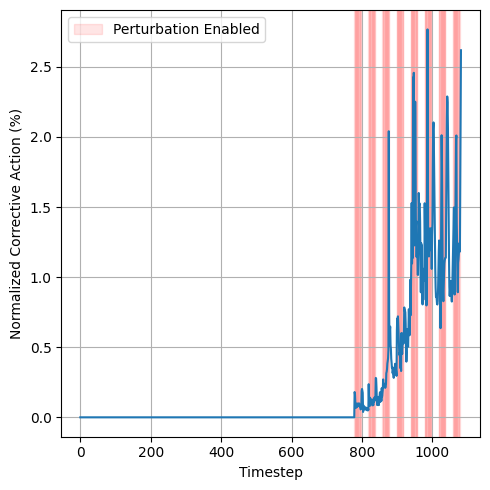

778 1082


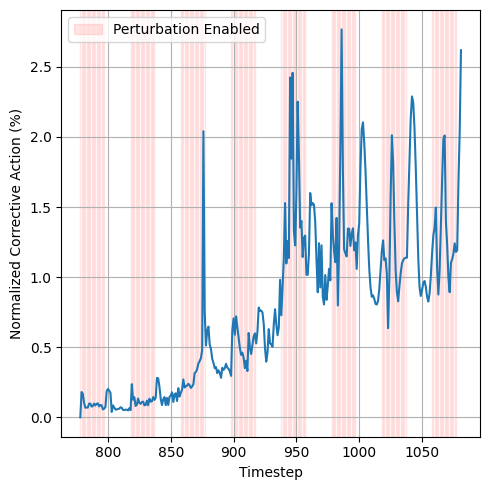

In [73]:
slip_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'slip')
    & (merged_df['learned_outcome'] == 'success')]

idx = 7
single_trial_df = raw_learned_data[slip_then_success_cases.index[idx]]
single_trial_df_no_perturb = raw_learned_no_perturb_data[slip_then_success_cases.index[idx]]

plot_trial_actions_mean_against_baseline(single_trial_df,
                                         single_trial_df_no_perturb)

plot_trial_actions_mean_against_baseline_during_perturb(single_trial_df,
                                         single_trial_df_no_perturb)

2


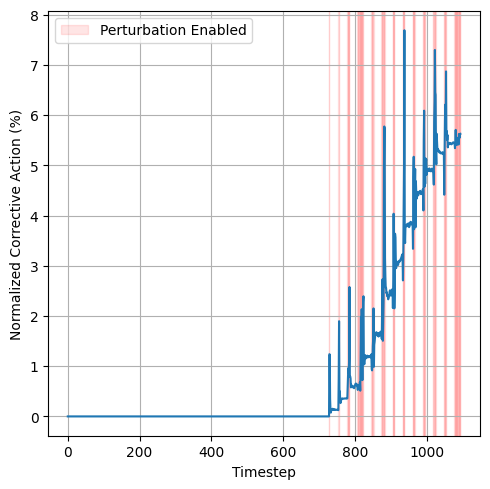

In [48]:
success_then_slip_cases = merged_df[
    (merged_df['baseline_outcome'] == 'success')
    & (merged_df['learned_outcome'] == 'slip')]

print(len(success_then_slip_cases))


single_trial_df = raw_learned_data[success_then_slip_cases.index[0]]
single_trial_df_no_perturb = raw_learned_no_perturb_data[success_then_slip_cases.index[0]]

plot_trial_actions_mean_against_baseline(single_trial_df, single_trial_df_no_perturb)

In [50]:
success_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'success')
    & (merged_df['learned_outcome'] == 'success')]

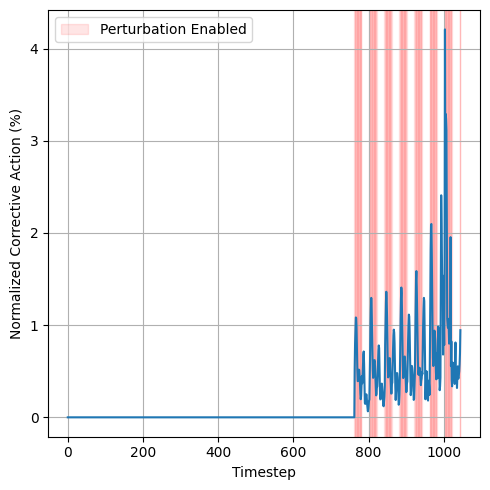

In [51]:
single_trial_df = raw_learned_data[0]
single_trial_df_no_perturb = raw_learned_no_perturb_data[0]

plot_trial_actions_mean_against_baseline(single_trial_df, single_trial_df_no_perturb)

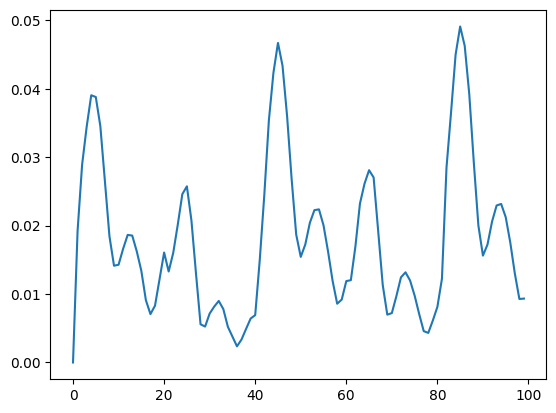

In [22]:
def get_trial_action_norm_after_perturb_start(data, data_perturbed):
    #stack data up
    actions_over_time = np.stack(data["action_hist"])
    perturbed_actions_over_time = np.stack(data_perturbed["action_hist"])

    #find index where perturbations start
    perturb_flags = data_perturbed['info_hist'].apply(
        lambda d: d['perturbation_enabled']).values
    start_idx = perturb_flags.argmax()

    diff = actions_over_time[start_idx:start_idx +
                             100] - perturbed_actions_over_time[
                                 start_idx:start_idx + 100]

    return np.linalg.norm(diff, axis=1)


norms = get_trial_action_norm_after_perturb_start(raw_learned_no_perturb_data[0], raw_learned_data[0])

plt.figure()
plt.plot(norms)
plt.show()

# how did actions differ under perturbations with outcome? 

(20, 100)
Average: 0.3979236549008122%
Max: 4.843398355264882 %
Median: 0.21049338671558693 %


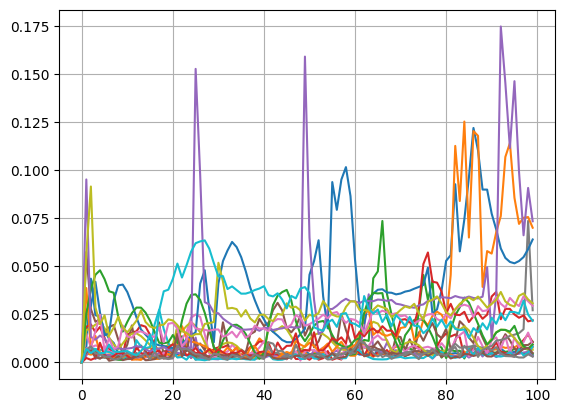

In [26]:
#get cases that were a slip and went to a success after learning, adjust all to start perturbations at 0, average
slip_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'slip')
    & (merged_df['learned_outcome'] == 'success')]

idx = slip_then_success_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_slip_to_success = np.array(norms_trajs)

print(norms_slip_to_success.shape)
print(f"Average: {100 * np.mean(norms_slip_to_success)/np.linalg.norm(np.ones(13))}%")
print(f"Max: {100 * np.max(norms_slip_to_success)/np.linalg.norm(np.ones(13))} %")
print(f"Median: {100 * np.median(norms_slip_to_success)/np.linalg.norm(np.ones(13))} %")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_slip_to_success[i, :])

plt.grid()


(815, 100)
Average: 0.2934007167652204%
Max: 12.179656908096952%
Median: 0.16058512165030947%


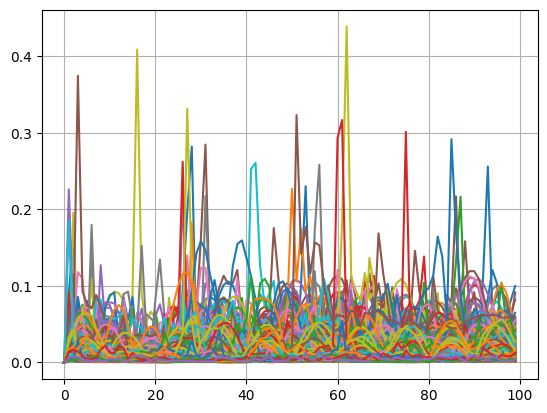

In [96]:
#get success then success as well
#find me the index of a case which was a slip, but turned into a fail?
success_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'success')
    & (merged_df['learned_outcome'] == 'success')]

idx = success_then_success_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_success_to_success = np.array(norms_trajs)

print(norms_success_to_success.shape)
print(f"Average: {100 * np.mean(norms_success_to_success)/np.linalg.norm(np.ones(13))}%")
print(f"Max: {100 * np.max(norms_success_to_success)/np.linalg.norm(np.ones(13))}%")
print(f"Median: {100 * np.median(norms_success_to_success)/np.linalg.norm(np.ones(13))}%")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_success_to_success[i, :])

plt.grid()

(48, 100)
Average: 1.0252657089631512%
max: 33.07941848889712%
median: 0.6834965127279845%


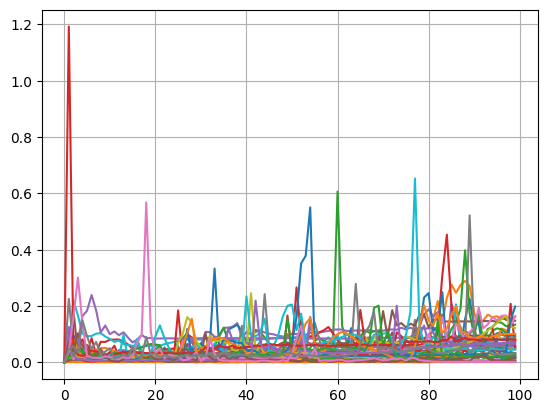

In [97]:
#get success then success as well
#find me the index of a case which was a slip, but turned into a fail?
slip_then_tip_cases = merged_df[
    (merged_df['baseline_outcome'] == 'slip')
    & (merged_df['learned_outcome'] == 'tip')]

idx = slip_then_tip_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_slip_to_tip = np.array(norms_trajs)

print(norms_slip_to_tip.shape)
print(f"Average: {100 * np.mean(norms_slip_to_tip)/np.linalg.norm(np.ones(13))}%")
print(f"max: {100 * np.max(norms_slip_to_tip)/np.linalg.norm(np.ones(13))}%")
print(f"median: {100 * np.median(norms_slip_to_tip)/np.linalg.norm(np.ones(13))}%")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_slip_to_tip[i, :])

plt.grid()

(15, 100)
Average: 0.5641757163951735%
max: 11.650306585459226%
median: 0.3549520945563948%


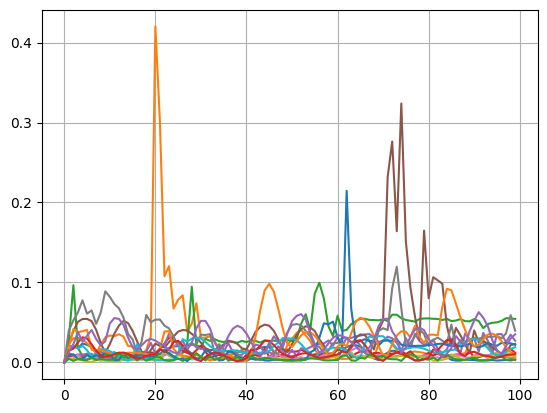

In [98]:
#get success then success as well
#find me the index of a case which was a slip, but turned into a fail?
tip_then_success_cases = merged_df[
    (merged_df['baseline_outcome'] == 'tip')
    & (merged_df['learned_outcome'] == 'success')]

idx = tip_then_success_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_tip_to_success = np.array(norms_trajs)

print(norms_tip_to_success.shape)
print(f"Average: {100 * np.mean(norms_tip_to_success)/np.linalg.norm(np.ones(13))}%")
print(f"max: {100 * np.max(norms_tip_to_success)/np.linalg.norm(np.ones(13))}%")
print(f"median: {100 * np.median(norms_tip_to_success)/np.linalg.norm(np.ones(13))}%")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_tip_to_success[i, :])

plt.grid()

(2, 100)
Average: 0.8473636494169059%
max: 3.8646797739992946%
median: 0.5842079586727414%


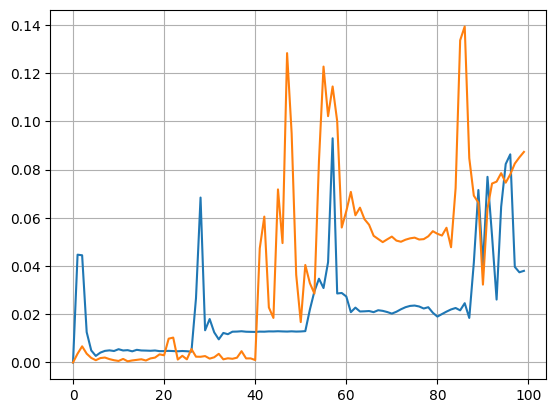

In [36]:
#get success then success as well
#find me the index of a case which was a slip, but turned into a fail?
success_then_slip_cases = merged_df[
    (merged_df['baseline_outcome'] == 'success')
    & (merged_df['learned_outcome'] == 'slip')]

idx = success_then_slip_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_success_to_slip = np.array(norms_trajs)

print(norms_success_to_slip.shape)
print(f"Average: {100 * np.mean(norms_success_to_slip)/np.linalg.norm(np.ones(13))}%")
print(f"max: {100 * np.max(norms_success_to_slip)/np.linalg.norm(np.ones(13))}%")
print(f"median: {100 * np.median(norms_success_to_slip)/np.linalg.norm(np.ones(13))}%")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_success_to_slip[i, :])

plt.grid()

(5, 100)
Average: 0.8503847582390655%
max: 3.6431864561271627%
median: 0.6189946011579691%


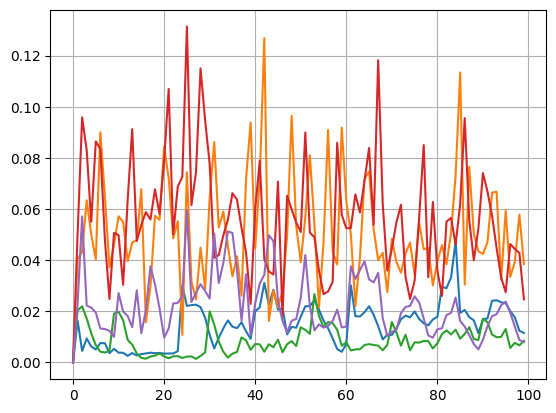

In [37]:
#get success then success as well
#find me the index of a case which was a slip, but turned into a fail?
success_then_tip_cases = merged_df[
    (merged_df['baseline_outcome'] == 'success')
    & (merged_df['learned_outcome'] == 'tip')]

idx = success_then_tip_cases.index

norms_trajs = []
for i in idx:
    perturb = raw_learned_data[i]
    no_perturb = raw_learned_no_perturb_data[i]
    norms = get_trial_action_norm_after_perturb_start(no_perturb, perturb)
    norms_trajs.append(norms)

norms_success_to_tip = np.array(norms_trajs)

print(norms_success_to_tip.shape)
print(f"Average: {100 * np.mean(norms_success_to_tip)/np.linalg.norm(np.ones(13))}%")
print(f"max: {100 * np.max(norms_success_to_tip)/np.linalg.norm(np.ones(13))}%")
print(f"median: {100 * np.median(norms_success_to_tip)/np.linalg.norm(np.ones(13))}%")

plt.figure()
for i in range(len(idx)):
    plt.plot(norms_success_to_tip[i, :])

plt.grid()